# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [19]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### Cargar Dataset

In [20]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [21]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
- La columna `ingreso_anual` tiene clientes con valores cero, es decir que el cliente no realizó compras en el año.
- La columna `edad` tiene tipo de dato float64, se debe convertir a tipo int64 (número entero).

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [22]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype('int64')
print(df['edad'].dtype)

int64


In [23]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [24]:
# Estadísticas descriptivas de variables numéricas
df[['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad` tiene rango de 18 a 75 años, la media y la mediana están alrededor de los 38 años, lo que indica una distribución simétrica o normal.
- `nivel_ingreso` tiene distribución normal de los datos; tiene alta dispersión de los datos con una desviación estándar de 9833.17
- `visitas_mes` tiene distribución normal de los datos; baja dispersión con una std de 3.16; el máximo de visitas por cliente es de 25.
- `compras_mes` tiene distribución normal; baja dispersión de los datos; un máximo de 8 compras por cliente.
- `gasto_publicidad_dirigida` tiene distribución normal; desviación estándar de 10.88; gasto de publicidad máximo por 27.29
- `satisfaccion` tiene muy bajas calificaciones como 1; tiene calificaciones de 5; el 75% de las calificaciones están por debajo de 4.1
- `ingreso_anual` tiene una distribución asimétrica de los datos, dado que hay datos outliers que aumentan la media como lo es 244.69; el 25% de los datos están en cero, se debe evaluar si estos datos son útiles para el análisis.


#### Explorar variables binarias

In [25]:
# Verificar que cada columna tenga únicamente dos valores posibles
print('Valores unicos columna miembro_premium:')
print(df['miembro_premium'].nunique())
print(df['miembro_premium'].unique())
print()
print('Valores unicos columna abandono:')
print(df['abandono'].nunique())
print(df['abandono'].unique())

Valores unicos columna miembro_premium:
2
[0 1]

Valores unicos columna abandono:
2
[0 1]


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium`: tiene 2 valores posibles 0 y 1 (premium o no)
- `abandono`: tiene 2 valores posibles 0 y 1 (abandonó la plataforma o no)

#### Explorar variables categóricas

In [26]:
# Verificar el número de valores únicos por variable categórica
print('Valores únicos por categoría')
print(df[['id_cliente', 'tipo_dispositivo', 'region']].nunique())
print()
print('Porcentajes de valores únicos por categoría')
print(df['tipo_dispositivo'].value_counts(normalize=True) * 100)

Valores únicos por categoría
id_cliente          15000
tipo_dispositivo        3
region                  4
dtype: int64

Porcentajes de valores únicos por categoría
móvil         65.453333
escritorio    24.800000
tablet         9.746667
Name: tipo_dispositivo, dtype: float64


In [27]:
# Explorar variables categóricas y cómo se distribuyen
print('Cantidades por categoría:')
print(df[['tipo_dispositivo', 'region']].value_counts())
print()
print('Porcentajes por categoría:')
print(df[['tipo_dispositivo', 'region']].value_counts(normalize=True) * 100)

Cantidades por categoría:
tipo_dispositivo  region
móvil             norte     2843
                  oeste     2489
                  sur       2483
                  este      2003
escritorio        norte     1125
                  oeste      935
                  sur        894
                  este       766
tablet            norte      427
                  oeste      386
                  sur        349
                  este       300
dtype: int64

Porcentajes por categoría:
tipo_dispositivo  region
móvil             norte     18.953333
                  oeste     16.593333
                  sur       16.553333
                  este      13.353333
escritorio        norte      7.500000
                  oeste      6.233333
                  sur        5.960000
                  este       5.106667
tablet            norte      2.846667
                  oeste      2.573333
                  sur        2.326667
                  este       2.000000
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo`: Hay 3 tipos; móvil, escritorio y tablet. El Móvil es el dispositivo dominante con el 65.45%, le siguen escritorio con 24.8% y tablet con 9.75%
- `region`:
- La región dominante en móvil es la norte con el 18.95%
- La región dominante en escritorio es la norte con el 7.5%
- La región dominante en tablet es la norte con el 2.84%
  
- En resumen, las categorías móvil y norte son las más dominantes. Hay un claro sesgo hacia dispositivos móviles en todas las regiones. Esto sugiere que los clientes de NovaRetail+ prefieren usar sus teléfonos para interactuar con la plataforma.
- Las distribuciones regionales por tipo de dispositivo están relativamente equilibradas, sin embargo, algunas regiones tienen ligeramente más clientes que otras.
- El análisis estará fuertemente influenciado por usuarios móviles.
- Las correlaciones pueden reflejar comportamientos específicos de móvil, lo más recomendable es segmentar para insights más acertados.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

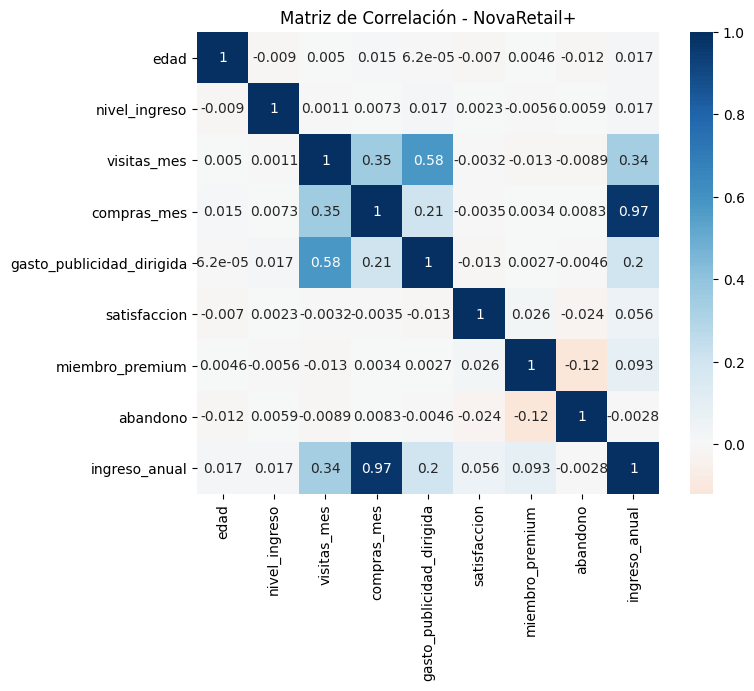

In [28]:
# Visualizar la matriz de correlación para identificar relaciones
corr= df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdBu', center=0, square=True)
plt.title('Matriz de Correlación - NovaRetail+')
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves

Observaciones generales (Heatmap)  
- Se observa que `visitas_mes` se correlaciona 0.58 con `gasto_publicidad_dirigida`: Los clientes con mayor gasto publicitario se asocian con más visitas mensuales.
- `visitas_mes` y `compras_mes` se correlacionan 0.35: Las visitas mensuales se asocian moderadamente con las compras.

Observaciones respecto a `ingreso_anual`  
- Presenta asociación muy fuerte 0.97 con `compras_mes`, esta fuerte asociación sugiere que ambas variables varían conjuntamente de manera casi perfecta, esto sugiere posible colinealidad entre estas variables.
- `visitas_mes` e `ingreso_anual` se correlacionan 0.34: Las visitas están asociadas moderadamente con el ingreso anual.
- `gasto_publicidad_dirigida` e `ingreso_anual` se correlacionan 0.2: el gasto de publicidad tiene una asociación muy débil con el ingreso anual. Lo que sugiere que el gasto de publicidad incide levemente en las ventas.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

Considero que no es necesario generar un scatterplot general, ya que en el Heatmap anterior se visualiza claramente las tendencias más fuertes entre variables, y en el siguiente punto del análisis se generarán scatterplots para pares clave, donde se graficarán las tendencias mas fuertes con el ingreso_anual.


### Scatterplot para pares clave

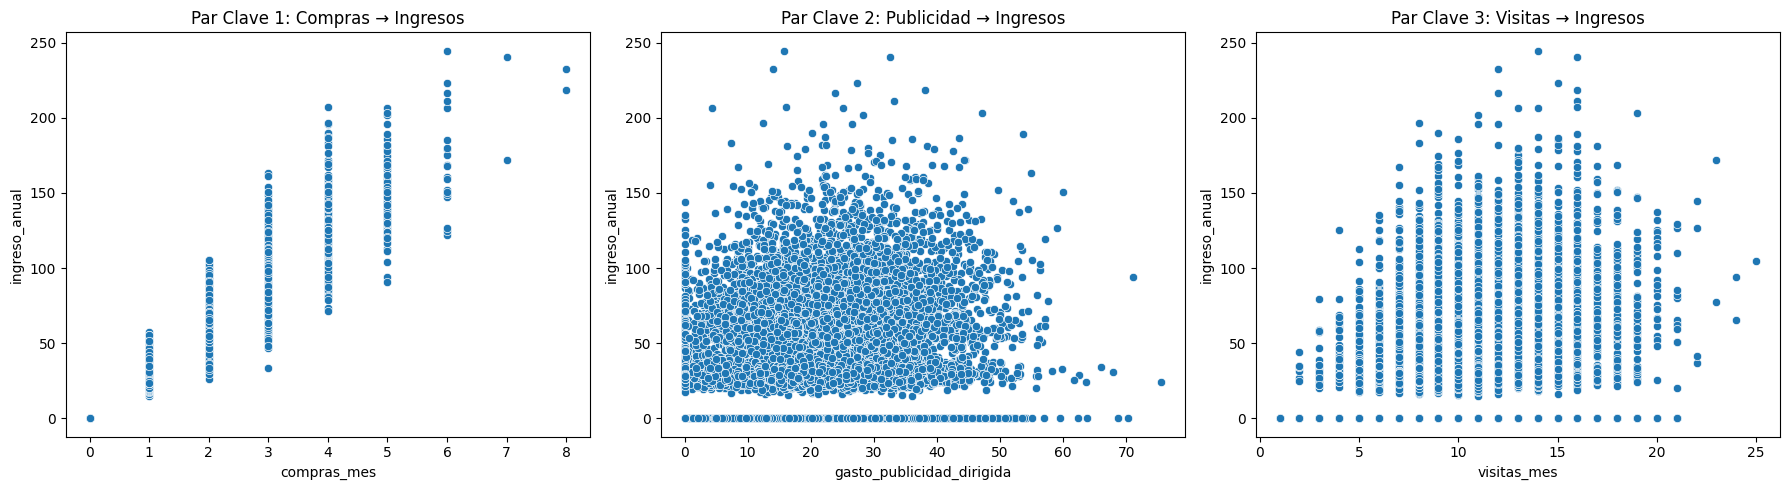

In [29]:
# Visualizar pares de variables con relaciones moderadas o fuertes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Par clave 1: Validación del modelo de negocio
sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual', ax=axes[0])
axes[0].set_title('Par Clave 1: Compras → Ingresos')

# Par clave 2: Efectividad publicitaria  
sns.scatterplot(data=df, x='gasto_publicidad_dirigida', y='ingreso_anual', ax=axes[1])
axes[1].set_title('Par Clave 2: Publicidad → Ingresos')

# Par clave 3: Conversión de visitantes
sns.scatterplot(data=df, x='visitas_mes', y='ingreso_anual', ax=axes[2])
axes[2].set_title('Par Clave 3: Visitas → Ingresos')

plt.tight_layout()
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.

Observaciones iniciales (Scatterplot)

**Compras vs Ingresos**
- Dirección positiva fuerte, con línea ascendente clara de izquierda a derecha.
- Dispersión muy baja, los puntos forman columnas verticales muy compactas.
- Pocos y leves outliers, algunos puntos están ligeramente separados en las columnas superiores (6-8 compras).
- Alta probabilidad de colinealidad, correlación visual casi perfecta (r≈0.97). Hay un patrón extremadamente lineal.

**Publicidad vs Ingresos**
- Dirección positiva: A medida que aumenta el gasto en publicidad dirigida, tiende a aumentar el ingreso anual. La nube de puntos muestra una tendencia ascendente general.
- Dispersión alta a media: Los puntos están bastante dispersos alrededor de la tendencia central. La variabilidad es considerable, especialmente en los niveles medios de gasto publicitario.
- Se identifican varios outliers:  Varios puntos con gasto publicitario muy alto (>60) pero ingresos relativamente bajos. Algunos puntos con gasto bajo (<20) pero ingresos altos (>200). Concentración notable de puntos en ingreso_anual = 0, que podrían ser valores atípicos o datos faltantes.
- Posibilidad de colinealidad: La relación positiva sugiere que estas variables podrían estar correlacionadas. Sin embargo, la alta dispersión indica que la correlación 0.2 es débil.

**Visitas vs Ingresos**
- Dirección positiva: Se observa una tendencia ascendente donde a mayor número de visitas, tiende a haber mayores ingresos anuales.
- Dispersión alta: Los puntos están muy dispersos alrededor de cualquier línea de tendencia imaginaria. Hay una gran variabilidad en los ingresos anuales para cualquier nivel dado de visitas.
- Varios outliers: Clientes con pocas visitas (5-10) pero ingresos altos (>150). Clientes con muchas visitas (15-20) pero ingresos relativamente bajos. Algunos puntos extremos en la parte superior del gráfico (>200).
- Moderada probabilidad de colinealidad: Aunque hay una tendencia positiva visible, la alta dispersión sugiere que las variables tienen una correlación moderada (0.34)


## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [30]:
# Calcular correlación entre variables relevantes
columnas_numericas = ['compras_mes', 'ingreso_anual', 'gasto_publicidad_dirigida', 'visitas_mes']
corr_pearson = df[columnas_numericas].corr(method='pearson')
print('Correlación de Pearson:')
print(corr_pearson)

Correlación de Pearson:
                           compras_mes  ingreso_anual  \
compras_mes                   1.000000       0.967149   
ingreso_anual                 0.967149       1.000000   
gasto_publicidad_dirigida     0.207528       0.197483   
visitas_mes                   0.353844       0.337147   

                           gasto_publicidad_dirigida  visitas_mes  
compras_mes                                 0.207528     0.353844  
ingreso_anual                               0.197483     0.337147  
gasto_publicidad_dirigida                   1.000000     0.578947  
visitas_mes                                 0.578947     1.000000  


In [31]:
# Calcular correlación entre variables relevantes
corr_spearman = df[columnas_numericas].corr(method='spearman')
print('Correlación de Spearman:')
print(corr_spearman)

Correlación de Spearman:
                           compras_mes  ingreso_anual  \
compras_mes                   1.000000       0.967482   
ingreso_anual                 0.967482       1.000000   
gasto_publicidad_dirigida     0.192511       0.184999   
visitas_mes                   0.332943       0.320954   

                           gasto_publicidad_dirigida  visitas_mes  
compras_mes                                 0.192511     0.332943  
ingreso_anual                               0.184999     0.320954  
gasto_publicidad_dirigida                   1.000000     0.559267  
visitas_mes                                 0.559267     1.000000  


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.

Observaciones de correlación

**Compras vs Ingresos**
- Correlación perfectamente lineal y fuerte, para pearson y spearman las correlaciones son muy similares (0.96)
- Dirección positiva fuerte, la correlación sugiere alta probabilidad de colinealidad.

**Publicidad vs Ingresos**
- Correlación lineal y moderada. Pearson: 0.197483 Spearman: 0.184999
- Baja posibilidad de colinealidad, dirección positiva.

**Visitas vs Ingresos**
- Correlación baja, los valores similares sugieren que las relaciones son lineales.
- Pearson: 0.337147 Spearman: 0.320954
- Dirección positiva moderada.

### Punto-biserial

In [32]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr
pointbiserialr(df['miembro_premium'], df['ingreso_anual'])

SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)

In [33]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr
pointbiserialr(df['abandono'], df['ingreso_anual'])

SignificanceResult(statistic=-0.002823934021617148, pvalue=0.7294691719078393)

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**miembro_premium vs ingreso_anual**
- Relación = 0.093 indica una asociación débil pero real. Los clientes premium y no premium si difieren en ingreso anual, pero en pequeña proporción.
- Los clientes premium tienden a generar ingresos anuales ligeramente diferentes a los no premium.

**abandono vs ingreso_anual**
- Relación= -0.0028 es muy débil, prácticamente inexistente. No existe una asociación estadísticamente significativa entre el abandono de la plataforma y el ingreso anual.

### V de Cramér

In [34]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency
col1 = 'tipo_dispositivo'
col2 = 'region'

def cramers_v(df, col_1, col_2):
    tabla = pd.crosstab(df[col_1], df[col_2])

    #calcular chi_cuadrado
    chi2, p_valor, dof, expected = chi2_contingency(tabla)

    # calcular coeficiente V de Cramér
    n = tabla.values.sum()
    coef_v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))

    # mostrar resultados
    print(f"V de Cramér ({col_1} vs {col_2}):", coef_v)

In [35]:
# Aplicar V de Cramér en variables relevantes
cramers_v(df, col1, col2)


V de Cramér (tipo_dispositivo vs region): 0.012378338407739397


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér = 0.012
- Asociación prácticamente nula entre `tipo_dispositivo` y `region` ya que el valor está muy cerca de cero.
- El tipo de dispositivo que usan los clientes es independiente de su región geográfica.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

✍️ **Hallazgos**: Completa los siguientes bloques.   
Si lo crees necesario, puedes agregar mas hallazgos.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### Hallazgo 1 — Compras e Ingresos

**Evidencia visual:**

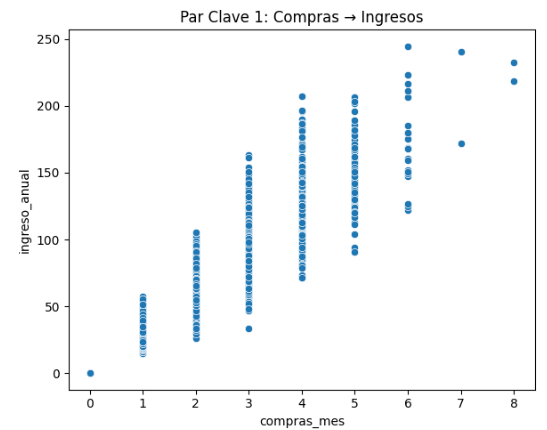


**Evidencia numérica:** 
- Correlación = 0.97
- Pearson y Spearman ≈ 0.97

**Interpretación**  

- Correlación lineal y fuerte, para pearson y spearman las correlaciones son muy similares (0.96)
- Dirección positiva fuerte, la correlación sugiere alta probabilidad de colinealidad.
- Alta probabilidad de colinealidad, correlación visual casi perfecta (r≈0.97). Esto sugiere un patrón extremadamente lineal.
  
**No podemos afirmar**  
- Que las variables son independientes.
- No podemos afirmar que no hay colinealidad entre las variables Compras e Ingresos.

**Implicación de negocio**  
- Segmentación: Clientes con pocas compras son candidatos claros para estrategias de activación.

### Hallazgo 2 — Publicidad e ingresos

**Evidencia visual:**   

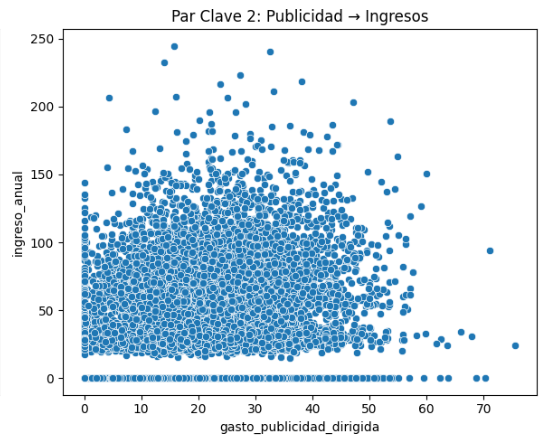

**Evidencia numérica:** 
- Correlación lineal y moderada. Pearson: 0.197483 Spearman: 0.184999

**Interpretación**  
- El aumento del gasto en publicidad dirigida, se asocia al aumento del ingreso anual.
- El gasto de publicidad tiene una asociación muy débil con el ingreso anual. Lo que sugiere que el gasto de publicidad incide levemente en las ventas.

**No podemos afirmar**  
Que aumentar el gasto de publicidad cause directamente más ingresos.

**Implicación de negocio**  
- Punto de rendimientos decrecientes: Después de ~$40-50 en gasto publicitario, la efectividad parece disminuir.
- Zona óptima: El rango de gasto publicidad 10-40 muestra la mejor relación costo-beneficio.
- Reconsiderar gastos altos: Clientes con gasto >60 no necesariamente generan más ingresos.

### Hallazgo 3 — Visitas e ingresos

**Evidencia visual:**   

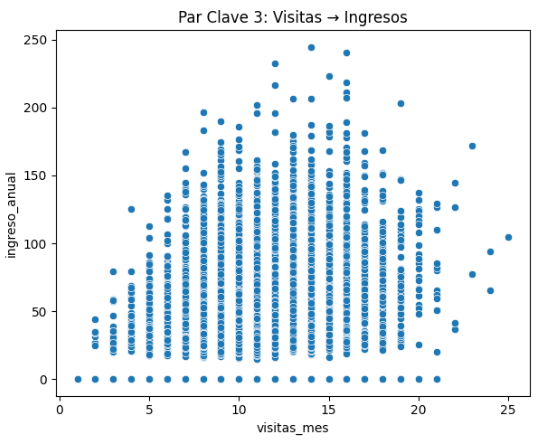


**Evidencia numérica:** 
- Pearson: 0.337147 Spearman: 0.320954

**Interpretación**  
- Se observa una tendencia ascendente donde a mayor número de visitas, tiende a haber mayores ingresos anuales.
- Después de 16 visitas el ingreso tiende a disminuir.

**No podemos afirmar**  
- Que aumentar visitas cause directamente más compras de clientes.

**Implicación de negocio**  
- Zona crítica (2-4 visitas): Clientes con pocas visitas pero altos ingresos son VIPs ocultos, se podría maximizar su experiencia.
- Zona de oportunidad (5-15 visitas): Mayor frecuencia de visitas correlaciona con mejores ingresos, se podría incentivar más visitas para posible aumento de ingresos.
- Zona de declive (16+ visitas): Rendimientos decrecientes sugieren posible saturación o fatiga del cliente.


## Sección 6 - Limitaciones y próximos pasos

✍️ **Comentario**: Completa el siguiente bloque.   
Modifica según creas necesario.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### **Limitaciones**
- Correlación ≠ causalidad
- Variables no analizadas (edades, nivel ingreso, satisfacción).
- Posibles efectos de segmentación no explorados.
  
### **Próximos pasos** 

Probar segmentación adicional
- [tipo_dispositivo]
- [region]

[Paso 2]
- Análisis por cohortes.

[Paso 3]
- Segmentación por edades, nivel ingreso, satisfacción.